## **Proyecto de Machine Learning: nomadismo digital y coste de vida global**

**Enfoque estratégico:** Clustering de ciudades como destino nómada digital & Regresión para predecir el score nómada de países en función de las variables. 

**Autores:** Daniela Aguirre, Agustín Arganín y Juan F. Cía

**Base del proyecto:** [EDA Nomadismo Digital](https://github.com/juanfcia/EDA-Nomadismo-Digital)

**Datasets y registros:**
1. **Registros:** 4,742 ciudades y 85 países. 
2. **Datasets:** [Variables agregadas](https://github.com/danielaaguirrej55-source/Proyecto-ML---Machine-Learning/blob/proj_ml_juanfcia/src/data_sample/cost-of-living-variables-agregadas.csv), [Mapa de variables](https://github.com/danielaaguirrej55-source/Proyecto-ML---Machine-Learning/blob/proj_ml_juanfcia/src/data_sample/cost-of-living-vars-map.csv), [Digital Nomad Index Circleloop](https://github.com/danielaaguirrej55-source/Proyecto-ML---Machine-Learning/blob/proj_ml_juanfcia/src/data_sample/digital-nomad-index-cicleloop-clean.csv) y [Digital Nomad Index Movingto](https://github.com/danielaaguirrej55-source/Proyecto-ML---Machine-Learning/blob/proj_ml_juanfcia/src/data_sample/digital-nomad-index-movingto-clean.csv).  
3. **Hipótesis validadas en el proyecto del EDA:** 9 hipótesis validadas

### **Problema de negocio**

#### **Contexto**

El nomadismo digital es un fenómeno creciente: profesionales que trabajan en remoto desde cualquier lugar del mundo. Elegir destino implica evaluar decenas de factores — coste de vida, conectividad, seguridad, calidad de vida — que interactúan de forma no lineal.

#### **Preguntas de negocio**

1. ¿Qué factores de coste de vida, conectividad y bienestar determinan el atractivo de un destino para nómadas digitales? 
2. ¿Podemos segmentar las ciudades del mundo en perfiles nómadas y predecir el score de un país?*

#### **Hallazgos del EDA que motivan este proyecto**

| Hallazgo | Estadístico | Implicación ML |
|---|---|---|
| **Conectividad** = predictor #1 del score nómada | r=0.73, p<0.001 | Feature de alta importancia |
| **Bienestar social** correlaciona fuertemente | r=0.70, p<0.001 | Feature de alta importancia |O
| **Los mejores destinos son más caros** | Top 20% coste mayor | Relación no lineal con el score |
| **Alimentación** pesa más que vivienda | Hipótesis rechada | Validar con feature importance |
| **Seguridad no tiene correlación fuerte** | r=0.18, p>0.05 | Variable de baja importancia |
| **Outliers value for money** identificados | Bajo coste + alto score | ¿Forman un clúster propio? |

#### **Enfoque estratético del proyecto**

Pipeline híbrido en 3 fases:

1. **Fase 1 — Clustering (aprendizaje no supervisado):** Segmentar 4,742 ciudades en perfiles nómadas usando 7 índices de coste de vida.
2. **Fase 2 — Regresión (aprendizaje supervisado):** Predecir el `digital_nomad_score` de 81 países usando indicadores de coste, conectividad, bienestar y los perfiles de cluster descubiertos en la fase 1.
3. **Fase 3 - Iteación añadiendo nuevos datos y ver variabilidad predictora:** Incluir datos de series temporales sobre inflación, ingresos por turismo, precio de la vivienda, clima... y analizar si los modelos baseline de fases 1 y 2 modifican su comportamiento para negocio. 

### **Carga de librerías y de datasets iniciales**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Sklearn - Preprocesado
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.feature_selection import SelectKBest, f_regression

# Sklearn - Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Sklearn - Regresión
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Guardado del modelo
import joblib

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Carga de datasets limpios del EDA

df_cities = pd.read_csv('../data_sample/cost-of-living-variables-agregadas.csv')
df_circleloop = pd.read_csv('../data_sample/digital-nomad-index-cicleloop-clean.csv')
df_movingto = pd.read_csv('../data_sample/digital-nomad-index-movingto-clean.csv')

In [4]:
# Número de registros y variables por cada uno de los datasets

print(f'Dataset 1: Cost of Living -> {df_cities.shape[0]} ciudades y {df_cities.shape[1]} variables')
print(f'Dataset 2: Circleloop -> {df_circleloop.shape[0]} países y {df_circleloop.shape[1]} variables')
print(f'Dataset 3: Movingto -> {df_movingto.shape[0]} países y {df_movingto.shape[1]} variables')

Dataset 1: Cost of Living -> 4742 ciudades y 65 variables
Dataset 2: Circleloop -> 85 países y 10 variables
Dataset 3: Movingto -> 40 países y 10 variables


In [5]:
# Imprimimos los tres datasets seguidos para echarle un vistazo

print('Dataset 1: Cost of Living -> 4742 ciudades y 65 variables')
display(df_cities.head(10))
print('Dataset 2: Circleloop -> 85 países y 10 variables')
display(df_circleloop.head(10))
print('Dataset 3: Movingto -> 40 países y 10 variables')
display(df_movingto.head(10))

Dataset 1: Cost of Living -> 4742 ciudades y 65 variables


,city_name,country_name,meal_inexpensive_restaurant,meal_midrange_restaurant_2p,mcmeal_fastfood,beer_domestic_restaurant_0_5l,beer_imported_restaurant_0_33l,cappuccino_restaurant,soda_restaurant_0_33l,water_restaurant_0_33l,...,mortgage_interest_rate_20y,data_quality_flag,continent,nomad_housing_cost,basic_basket_index,daily_meal_cost,monthly_nomad_cost,local_purchasing_power,cappuccino_index,housing_salary_ratio
0,Seoul,South Korea,7.68,53.78,6.15,3.07,4.99,3.93,1.48,0.79,...,3.47,1,Asia,650.030,4.631667,11.61,1209.990,2.222845,37.934560,24.168098
1,Shanghai,China,5.69,39.86,5.69,1.14,4.27,3.98,0.53,0.33,...,5.03,1,Asia,830.905,1.995000,9.67,1147.345,1.237527,38.445808,58.519794
2,Guangzhou,China,4.13,28.47,4.98,0.85,1.71,3.54,0.44,0.33,...,5.19,1,Asia,425.365,1.572500,7.67,692.370,1.750047,33.946830,35.105391
3,Mumbai,India,3.68,18.42,3.68,2.46,4.30,2.48,0.48,0.19,...,7.96,1,Asia,408.225,1.078333,6.16,590.785,1.084675,23.108384,63.704530
4,Delhi,India,4.91,22.11,4.30,1.84,3.68,1.77,0.49,0.19,...,8.06,1,Asia,182.575,1.047500,6.68,391.890,1.496491,15.848671,31.131705
5,Dhaka,Bangladesh,1.95,11.71,4.88,5.85,5.12,1.95,0.29,0.16,...,9.26,1,Asia,114.940,1.193333,3.90,286.730,0.979074,17.689162,40.943255
6,Osaka,Japan,7.45,48.39,5.36,3.35,3.72,3.28,1.09,0.81,...,1.49,1,Asia,525.550,3.302500,10.73,1035.305,2.243262,31.288344,22.629023
7,Jakarta,Indonesia,2.59,22.69,3.57,2.06,3.24,2.23,0.61,0.27,...,9.05,1,Asia,391.510,1.765000,4.82,643.550,0.791112,20.552147,76.899356
8,Shenzhen,China,4.27,28.47,4.98,1.14,3.99,4.20,0.47,0.34,...,4.99,1,Asia,586.910,1.829167,8.47,890.265,1.766013,40.695297,37.330017
9,Kinshasa,Congo,15.11,42.63,10.08,1.74,2.50,4.35,2.78,0.84,...,19.33,0,Africa,1362.500,4.215000,19.46,2664.840,0.150103,42.229039,340.625000


Dataset 2: Circleloop -> 85 países y 10 variables


,rank,country,broadband_speed_mbps,mobile_speed_mbps,broadband_cost,monthly_rent,happiness_index,migrant_population_pct,remote_jobs_searches,digital_nomad_score
0,1,Canada,149.35,84.54,41.17,1045.0,7.23,21.3,83900,74.35
1,2,UK,76.49,41.72,42.18,1019.7,7.17,14.1,68400,63.43
2,3,Romania,188.55,41.48,9.63,357.5,6.12,2.4,10980,62.28
3,4,Sweden,158.73,56.64,46.77,973.5,7.35,20.0,3490,61.54
4,5,Denmark,179.81,66.68,56.96,1164.9,7.65,12.5,1080,61.49
5,6,France,177.93,50.45,32.84,833.8,6.66,12.8,5360,60.80
6,7,Netherlands,125.82,88.13,50.11,1334.3,7.45,13.4,3440,60.27
7,8,Australia,58.52,88.35,57.11,1262.8,7.22,30.0,17600,60.16
8,9,Switzerland,186.40,73.85,85.15,1699.5,7.56,29.9,3840,60.15
9,10,Germany,120.13,49.67,33.95,906.4,7.08,15.7,12720,60.00


Dataset 3: Movingto -> 40 países y 10 variables


,rank,country,overall_score,internet_speed,cost_of_living,safety,visa_ease,quality_of_life,taxes,tax_free_period
0,1,Portugal,92,90,85,95,95,95,NHR 20%,10 years
1,2,Estonia,91,95,75,90,98,92,0-20%,183 days/year
2,3,Georgia,90,85,88,82,100,80,1%,183 days/year
3,4,Spain,89,88,80,92,92,94,24%,183 days/year
4,5,Thailand,88,85,95,80,90,88,0-35%,183 days/year
5,6,Mexico,87,82,90,75,94,86,1.92-35%,183 days/year
6,7,Czech Republic,86,87,78,88,85,90,15%,183 days/year
7,8,Malaysia,85,80,92,85,90,85,0-30%,182 days/year
8,9,Croatia,84,84,76,88,88,89,24%,1 year
9,10,Costa Rica,83,79,85,80,90,88,0-25%,183 days/year


#### ***Analizamos dataset 1 `df_cities`: variables agregadas***

In [6]:
df_cities.info() # Aquí teníamos el dataset global con todas las variables, incluidas las agregadas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4742 entries, 0 to 4741
Data columns (total 65 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   city_name                            4742 non-null   object 
 1   country_name                         4742 non-null   object 
 2   meal_inexpensive_restaurant          4742 non-null   float64
 3   meal_midrange_restaurant_2p          4742 non-null   float64
 4   mcmeal_fastfood                      4742 non-null   float64
 5   beer_domestic_restaurant_0_5l        4742 non-null   float64
 6   beer_imported_restaurant_0_33l       4742 non-null   float64
 7   cappuccino_restaurant                4742 non-null   float64
 8   soda_restaurant_0_33l                4742 non-null   float64
 9   water_restaurant_0_33l               4742 non-null   float64
 10  milk_1l                              4742 non-null   float64
 11  bread_white_500g              

In [7]:
df_cities.describe() # Descriptivos del dataset global de coste de vida y variables agregadas

,meal_inexpensive_restaurant,meal_midrange_restaurant_2p,mcmeal_fastfood,beer_domestic_restaurant_0_5l,beer_imported_restaurant_0_33l,cappuccino_restaurant,soda_restaurant_0_33l,water_restaurant_0_33l,milk_1l,bread_white_500g,...,avg_net_salary,mortgage_interest_rate_20y,data_quality_flag,nomad_housing_cost,basic_basket_index,daily_meal_cost,monthly_nomad_cost,local_purchasing_power,cappuccino_index,housing_salary_ratio
count,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,...,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000
mean,10.391314,43.244941,6.901185,3.391245,3.923038,2.744212,1.541647,1.116082,1.144315,1.648491,...,1870.479792,6.529655,0.194644,636.678457,2.354338,13.135526,1223.499553,1.519773,25.809942,47.392698
std,7.023919,25.143035,2.693939,2.086401,2.094815,1.351879,0.894991,0.752165,0.508499,1.085200,...,1600.985025,5.345518,0.395968,553.182086,1.168741,7.959227,7094.608473,0.746821,13.822897,75.850224
min,0.450000,3.250000,1.080000,0.330000,0.310000,0.220000,0.110000,0.070000,0.260000,0.050000,...,18.000000,0.780000,0.000000,18.985000,0.485833,1.100000,108.085000,0.001476,0.000000,2.937660
25%,4.482500,22.196250,4.980000,1.600000,2.170000,1.580000,0.790000,0.480000,0.840000,0.810000,...,456.002500,3.112500,0.000000,219.809375,1.443125,6.372500,491.875000,0.970096,13.905930,26.951940
50%,10.000000,40.000000,6.895000,3.000000,3.640000,2.620000,1.500000,1.050000,1.030000,1.360000,...,1369.870000,5.360000,0.000000,471.722500,2.080417,12.255000,967.958750,1.458705,24.539877,34.676347
75%,15.000000,60.000000,8.430000,5.000000,5.270000,3.750000,2.110000,1.590000,1.300000,2.310000,...,3075.000000,8.330000,0.000000,945.632500,3.137500,18.920000,1642.790000,1.936327,36.094070,49.121786
max,57.140000,213.690000,22.130000,20.600000,17.500000,10.000000,8.000000,5.850000,6.810000,8.820000,...,12821.400000,61.330000,1.000000,10799.100000,10.302500,64.280000,486948.090000,7.939058,100.000000,2191.420280


In [8]:
# Descriptivos de las variables agregadas que usamos como hipótesis en el EDA de Nomadismo Digital
# Aquí ya podemos ver que vamos a tener que escalar a la hora de incluirlas en el modelo
# El orden de magnitud de las distintas variables es muy variable

print('Variables coste de vida mensual')
display(df_cities.monthly_nomad_cost.describe())
print('Variable poder adquisitivo')
display(df_cities.local_purchasing_power.describe())
print('Variables de coste en vivienda')
display(df_cities.nomad_housing_cost.describe())
print('Variables Ratio de gasto de salario en vivienda')
display(df_cities.housing_salary_ratio.describe())
print('Variables coste de la cesta de compra')
display(df_cities.basic_basket_index.describe())
print('Variable coste diario en salir a comer fuera')
display(df_cities.daily_meal_cost.describe())
print('Variable precio de un cappucino como unidad estándar de coste de vida')
display(df_cities.cappuccino_index.describe())

Variables coste de vida mensual


count      4742.000000
mean       1223.499553
std        7094.608473
min         108.085000
25%         491.875000
50%         967.958750
75%        1642.790000
max      486948.090000
Name: monthly_nomad_cost, dtype: float64

Variable poder adquisitivo


count    4742.000000
mean        1.519773
std         0.746821
min         0.001476
25%         0.970096
50%         1.458705
75%         1.936327
max         7.939058
Name: local_purchasing_power, dtype: float64

Variables de coste en vivienda


count     4742.000000
mean       636.678457
std        553.182086
min         18.985000
25%        219.809375
50%        471.722500
75%        945.632500
max      10799.100000
Name: nomad_housing_cost, dtype: float64

Variables Ratio de gasto de salario en vivienda


count    4742.000000
mean       47.392698
std        75.850224
min         2.937660
25%        26.951940
50%        34.676347
75%        49.121786
max      2191.420280
Name: housing_salary_ratio, dtype: float64

Variables coste de la cesta de compra


count    4742.000000
mean        2.354338
std         1.168741
min         0.485833
25%         1.443125
50%         2.080417
75%         3.137500
max        10.302500
Name: basic_basket_index, dtype: float64

Variable coste diario en salir a comer fuera


count    4742.000000
mean       13.135526
std         7.959227
min         1.100000
25%         6.372500
50%        12.255000
75%        18.920000
max        64.280000
Name: daily_meal_cost, dtype: float64

Variable precio de un cappucino como unidad estándar de coste de vida


count    4742.000000
mean       25.809942
std        13.822897
min         0.000000
25%        13.905930
50%        24.539877
75%        36.094070
max       100.000000
Name: cappuccino_index, dtype: float64

In [9]:
# Número de páises totales, países por continentes y nulos (df limpio)

print(f'Ciudades únicas: {df_cities.city_name.nunique()}')
print(f'Países únicos: {df_cities.country_name.nunique()}')
print(f'Continentes: {df_cities.continent.value_counts().to_dict()}')
print(f'Nulos: {df_cities.isnull().sum().sum()}')

Ciudades únicas: 4700
Países únicos: 214
Continentes: {'Europe': 1730, 'North America': 1338, 'Asia': 961, 'Africa': 311, 'South America': 305, 'Oceania': 97}
Nulos: 0


#### ***Analizamos dataset 2 `df_circleloop`***

Contiene el target de la regresión -> digital_nomad_score

In [10]:
df_circleloop.info() # Variables y su tipo 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   rank                    85 non-null     int64  
 1   country                 85 non-null     object 
 2   broadband_speed_mbps    85 non-null     float64
 3   mobile_speed_mbps       85 non-null     float64
 4   broadband_cost          85 non-null     float64
 5   monthly_rent            85 non-null     float64
 6   happiness_index         85 non-null     float64
 7   migrant_population_pct  85 non-null     float64
 8   remote_jobs_searches    85 non-null     int64  
 9   digital_nomad_score     85 non-null     float64
dtypes: float64(7), int64(2), object(1)
memory usage: 6.8+ KB


In [11]:
print(f'Nulos: {df_circleloop.isnull().sum().sum()}') # Dataset limpio procedente del EDA

Nulos: 0


In [12]:
df_circleloop.describe() # Descriptivos del dataset de Circleloop

,rank,broadband_speed_mbps,mobile_speed_mbps,broadband_cost,monthly_rent,happiness_index,migrant_population_pct,remote_jobs_searches,digital_nomad_score
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,43.000000,81.160706,42.682118,45.149176,670.280353,6.055647,11.510588,4741.647059,49.118824
std,24.681302,56.411813,23.164497,26.105156,442.527594,0.891339,15.386574,12279.242051,10.099860
min,1.000000,4.970000,12.680000,7.850000,136.400000,4.150000,0.100000,40.000000,26.320000
25%,22.000000,31.890000,24.630000,29.590000,359.700000,5.510000,1.700000,430.000000,38.970000
50%,43.000000,68.900000,38.880000,42.510000,524.700000,6.120000,5.300000,1050.000000,52.080000
75%,64.000000,120.130000,53.890000,56.180000,886.600000,6.660000,15.400000,3490.000000,56.570000
max,85.000000,229.420000,129.610000,172.310000,2305.600000,7.810000,87.900000,83900.000000,74.350000


In [13]:
# Análisis de descriptivos de la variable target en regresión -> digital_nomad_score

print('Descriptivos de la variable target del análisis de regresión')
display(df_circleloop.digital_nomad_score.describe()) 

Descriptivos de la variable target del análisis de regresión


count    85.000000
mean     49.118824
std      10.099860
min      26.320000
25%      38.970000
50%      52.080000
75%      56.570000
max      74.350000
Name: digital_nomad_score, dtype: float64

In [14]:
# Análisis de descriptivos de otras variables que sirvieron de hipótesis en el EDA

print('Descriptivos de la variable Velocidad de internet')
display(df_circleloop.broadband_speed_mbps.describe()) 
print('Descriptivos de la variable Velocidad de internet en móvil')
display(df_circleloop.mobile_speed_mbps.describe()) 
print('Descriptivos de la variable Bienestar social')
display(df_circleloop.happiness_index.describe()) 
print('Descriptivos de la variable Porcentaje de la población inmigrante')
display(df_circleloop.migrant_population_pct.describe()) 

Descriptivos de la variable Velocidad de internet


count     85.000000
mean      81.160706
std       56.411813
min        4.970000
25%       31.890000
50%       68.900000
75%      120.130000
max      229.420000
Name: broadband_speed_mbps, dtype: float64

Descriptivos de la variable Velocidad de internet en móvil


count     85.000000
mean      42.682118
std       23.164497
min       12.680000
25%       24.630000
50%       38.880000
75%       53.890000
max      129.610000
Name: mobile_speed_mbps, dtype: float64

Descriptivos de la variable Bienestar social


count    85.000000
mean      6.055647
std       0.891339
min       4.150000
25%       5.510000
50%       6.120000
75%       6.660000
max       7.810000
Name: happiness_index, dtype: float64

Descriptivos de la variable Porcentaje de la población inmigrante


count    85.000000
mean     11.510588
std      15.386574
min       0.100000
25%       1.700000
50%       5.300000
75%      15.400000
max      87.900000
Name: migrant_population_pct, dtype: float64

#### ***Analizamos dataset 3 `df_movingto`***

In [15]:
df_movingto.info() # Variables y su tipo 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   rank             40 non-null     int64 
 1   country          40 non-null     object
 2   overall_score    40 non-null     int64 
 3   internet_speed   40 non-null     int64 
 4   cost_of_living   40 non-null     int64 
 5   safety           40 non-null     int64 
 6   visa_ease        40 non-null     int64 
 7   quality_of_life  40 non-null     int64 
 8   taxes            40 non-null     object
 9   tax_free_period  40 non-null     object
dtypes: int64(7), object(3)
memory usage: 3.3+ KB


In [16]:
print(f'Nulos: {df_movingto.isnull().sum().sum()}') # Dataset limpio procedente del EDA

Nulos: 0


In [17]:
# Análisis de descriptivos de otras variables que sirvieron de hipótesis en el EDA

print('Descriptivos de la variable Seguridad')
display(df_movingto.safety.describe()) 
print('Descriptivos de la variable Facilidad a la hora de conseguir visa')
display(df_movingto.visa_ease.describe()) 

Descriptivos de la variable Seguridad


count    40.000000
mean     84.250000
std       8.325894
min      65.000000
25%      78.750000
50%      85.000000
75%      90.000000
max      95.000000
Name: safety, dtype: float64

Descriptivos de la variable Facilidad a la hora de conseguir visa


count     40.000000
mean      85.050000
std        7.085377
min       70.000000
25%       80.000000
50%       85.000000
75%       90.000000
max      100.000000
Name: visa_ease, dtype: float64

#### Resumen de los datasets:

- En conjunto, los tres datasets utilizados están limpios, completos y sin valores nulos, lo que facilita su integración y análisis. Cada uno aporta una perspectiva complementaria: *df_cities* ofrece una visión amplia del coste de vida y condiciones económicas de las ciudades, *df_circleloop* incorpora variables clave para analizar el *digital nomad score* desde un enfoque de regresión, y *df_movingto* añade indicadores relacionados con calidad de vida, seguridad y facilidad de visado. En conjunto, forman una base sólida para el análisis exploratorio, el clustering y el modelado posterior.


### **MiniEDA de las variables que usaremos en el proyecto de Machine Learning**

In [18]:
# Variables sobre las que sacaremos el clusterizado de ciudades

nom_features= [
    'monthly_nomad_cost',
    'nomad_housing_cost',
    'basic_basket_index',
    'daily_meal_cost',
    'local_purchasing_power',
    'cappuccino_index',
    'housing_salary_ratio'
]

In [19]:
df_cities[nom_features].describe().round(2)

,monthly_nomad_cost,nomad_housing_cost,basic_basket_index,daily_meal_cost,local_purchasing_power,cappuccino_index,housing_salary_ratio
count,4742.00,4742.00,4742.00,4742.00,4742.00,4742.00,4742.00
mean,1223.50,636.68,2.35,13.14,1.52,25.81,47.39
std,7094.61,553.18,1.17,7.96,0.75,13.82,75.85
min,108.08,18.98,0.49,1.10,0.00,0.00,2.94
25%,491.88,219.81,1.44,6.37,0.97,13.91,26.95
50%,967.96,471.72,2.08,12.26,1.46,24.54,34.68
75%,1642.79,945.63,3.14,18.92,1.94,36.09,49.12
max,486948.09,10799.10,10.30,64.28,7.94,100.00,2191.42


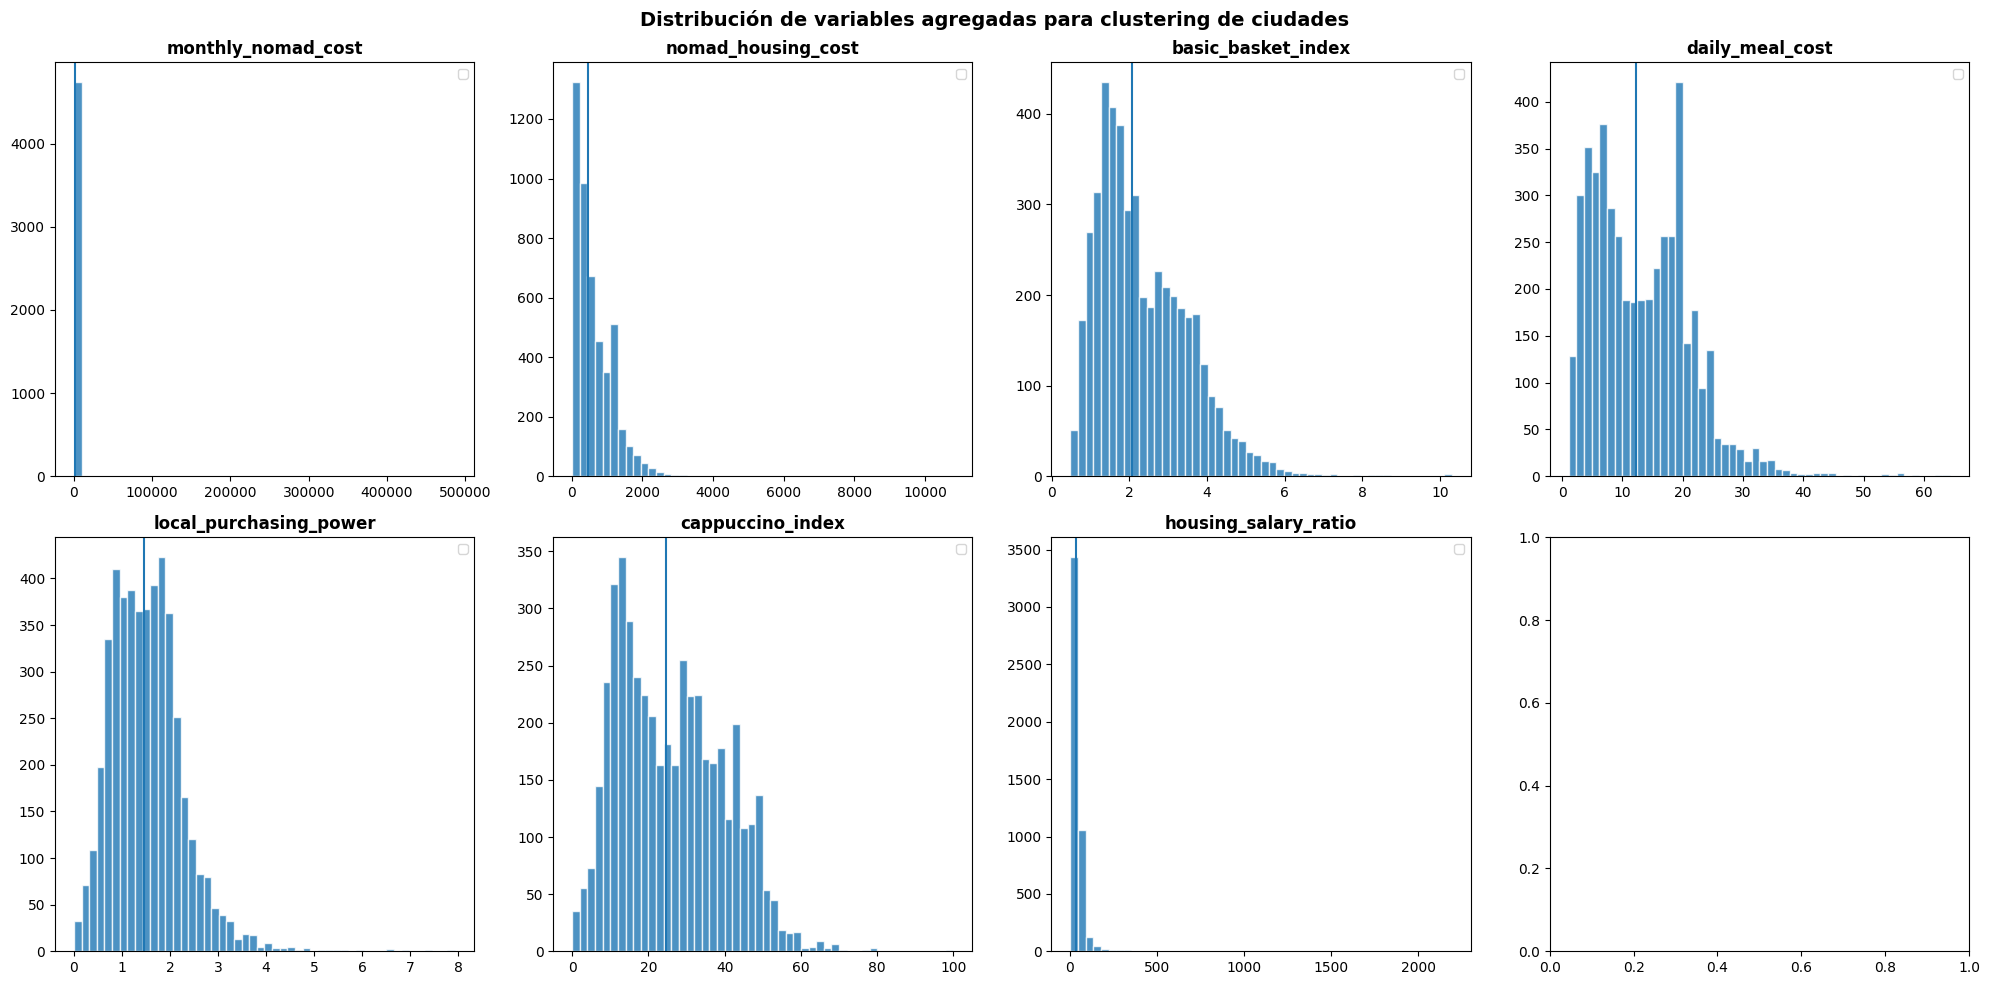

In [20]:
# Distribuciones de las features de clustering

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(nom_features):
    axes[i].hist(df_cities[col], bins=50, edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].axvline(df_cities[col].median())
    axes[i].legend(fontsize=9)

fig.suptitle('Distribución de variables agregadas para clustering de ciudades', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

- Las variables elegidas para el clustering recogen distintas dimensiones del coste de vida y de la capacidad económica de cada ciudad, por lo que resultan adecuadas para construir grupos comparables de destinos nómadas. A partir de los histogramas, se observa que la mayoría presentan asimetría positiva, especialmente *monthly_nomad_cost*, *nomad_housing_cost* y *housing_salary_ratio*, lo que indica la presencia de valores extremos altos y ciudades significativamente más costosas que la mayoría.

- Por otro lado, variables como *basic_basket_index, daily_meal_cost, local_purchasing_power y cappuccino_index* muestran distribuciones más concentradas, aunque también con cierta dispersión. En conjunto, esto sugiere que las variables no están en la misma escala y que algunas presentan sesgo y outliers, por lo que será necesario aplicar un proceso de escalado antes de entrenar el modelo de clustering, para evitar que las variables con mayor magnitud dominen la segmentación.

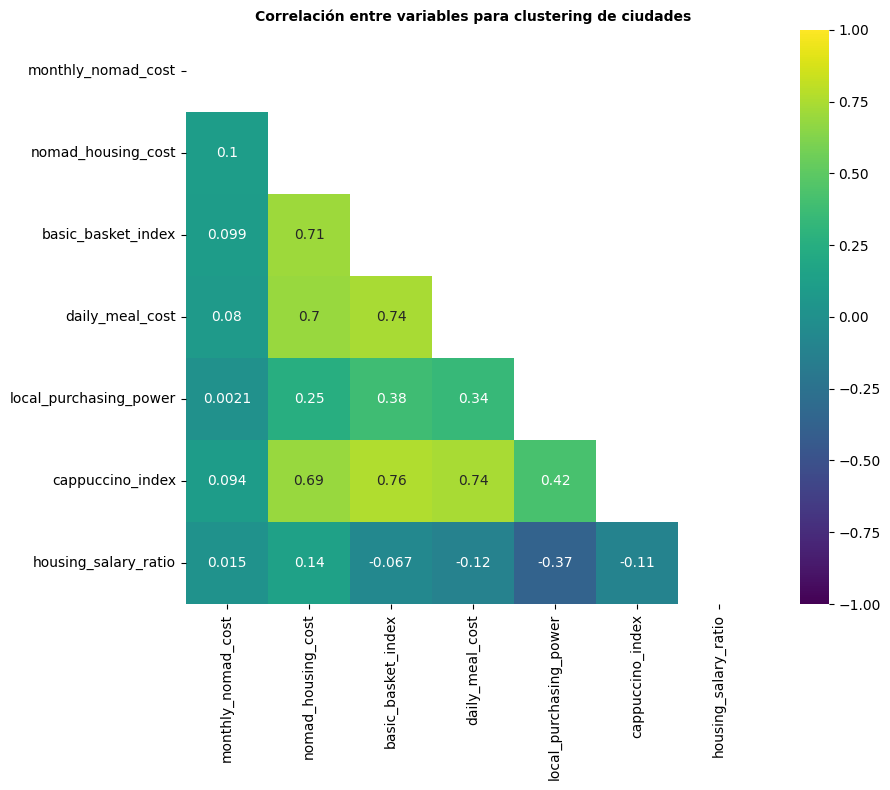

In [21]:
# Correlación entre features para clustering de ciudades

corr_features = df_cities[nom_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_features))
sns.heatmap(corr_features, 
            mask=mask, 
            annot=True, 
            cmap='viridis',
            center=0, 
            vmin=-1, 
            vmax=1, 
            ax=ax, 
            square=True)
ax.set_title('Correlación entre variables para clustering de ciudades', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

- La matriz de correlación muestra que varias variables de coste de vida presentan una relación positiva moderada-alta entre sí. En particular, *basic_basket_index, daily_meal_cost y cappuccino_index* están bastante correlacionadas, lo que indica que capturan dimensiones similares del nivel de precios en cada ciudad. También *nomad_housing_cost* mantiene correlaciones elevadas con estas variables, especialmente con el coste de la cesta básica y el coste de comer fuera.

- Por otro lado, *local_purchasing_power* presenta correlaciones positivas más moderadas con las variables de coste, mientras que *housing_salary_ratio* muestra correlaciones débiles o ligeramente negativas, sobre todo con el poder adquisitivo local. Esto sugiere que esta variable aporta una dimensión diferente, relacionada con la presión que supone la vivienda respecto al salario y no solo con el nivel general de precios.

- En conjunto, la matriz confirma que existen variables parcialmente relacionadas, pero no completamente redundantes, por lo que su combinación sigue siendo útil para segmentar ciudades desde distintas perspectivas económicas.

Text(0, 0.5, 'digital_nomad_score')

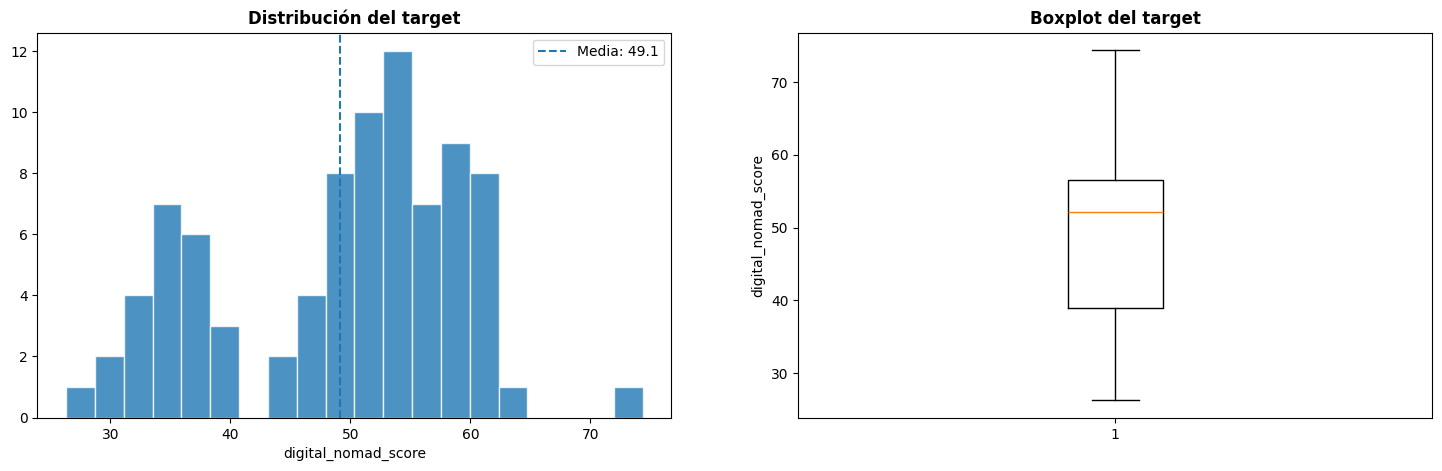

In [22]:
# Análisis del target: digital_nomad_score

target = "digital_nomad_score"

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Distribución con histograma

axes[0].hist(df_circleloop[target], bins=20, edgecolor='white', alpha=0.8)
axes[0].axvline(df_circleloop[target].mean(), linestyle='--', label=f"Media: {df_circleloop[target].mean():.1f}")
axes[0].set_title('Distribución del target', fontweight='bold')
axes[0].set_xlabel(target)
axes[0].legend()

# Boxplot para ver estadíticos y outliers 

axes[1].boxplot(df_circleloop[target], vert=True)
axes[1].set_title('Boxplot del target', fontweight='bold')
axes[1].set_ylabel(target)

- En conjunto, la variable objetivo presenta una distribución adecuada para el modelado, ya que no está excesivamente concentrada ni completamente sesgada hacia un solo rango de valores, presenta una distribución relativamente equilibrada, concentrada en torno a valores medios, con una media cercana a 49,1 lo que indica una dispersión moderada y una variabilidad suficiente para el análisis de regresión.

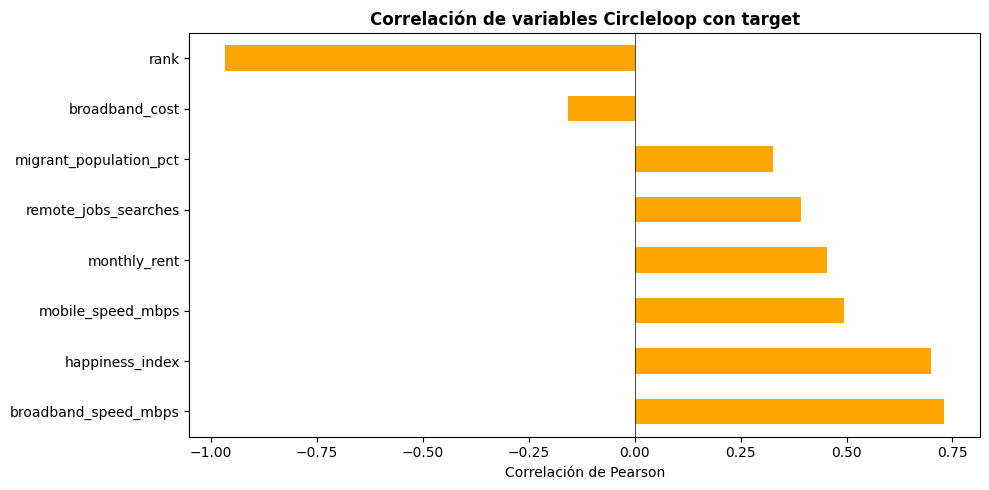

In [23]:
# Correlaciones de variables Circleloop con el target

corr_target = df_circleloop.select_dtypes(include='number').corr()[target].drop(target).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
corr_target.plot(kind='barh', ax=ax, color='orange', edgecolor='none')
ax.set_title('Correlación de variables Circleloop con target', fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

- Las correlaciones muestran que *broadband_speed_mbps* y *happiness_index* son las variables con mayor relación positiva con *digital_nomad_score*, este análisis permite identificar qué variables parecen más relevantes para explicar el *digital_nomad_score* antes de entrenar el modelo.

### **Tratamiento de variables y clustering de ciudades**

In [24]:
# Preparación de variables para el clustering de ciudades como destinos nómadas digitales
# Creamos un dataframe con todas las variables a partir de una copia de df_cities

df_clustering = df_cities[['city_name', 'country_name', 'continent'] + nom_features].copy()

In [25]:
print(df_clustering[nom_features].isnull().sum().sum()) # No tiene nulos
print(df_clustering.shape) # Tiene todas las ciudades y 10 variables 

0
(4742, 10)


In [26]:
# Quitamos outliers en todas las variables agregadas porque puede deformar los clusters posteriores

for col in nom_features:
    p99 = df_clustering[col].quantile(0.99)
    p01 = df_clustering[col].quantile(0.01)
    df_clustering[col] = df_clustering[col].clip(lower=p01, upper=p99)

In [27]:
# Y ahora las escalamos para normalizar los órdenes de magnitud de todas ellas

scaler_clustering = StandardScaler()
X_clustering = scaler_clustering.fit_transform(df_clustering[nom_features])

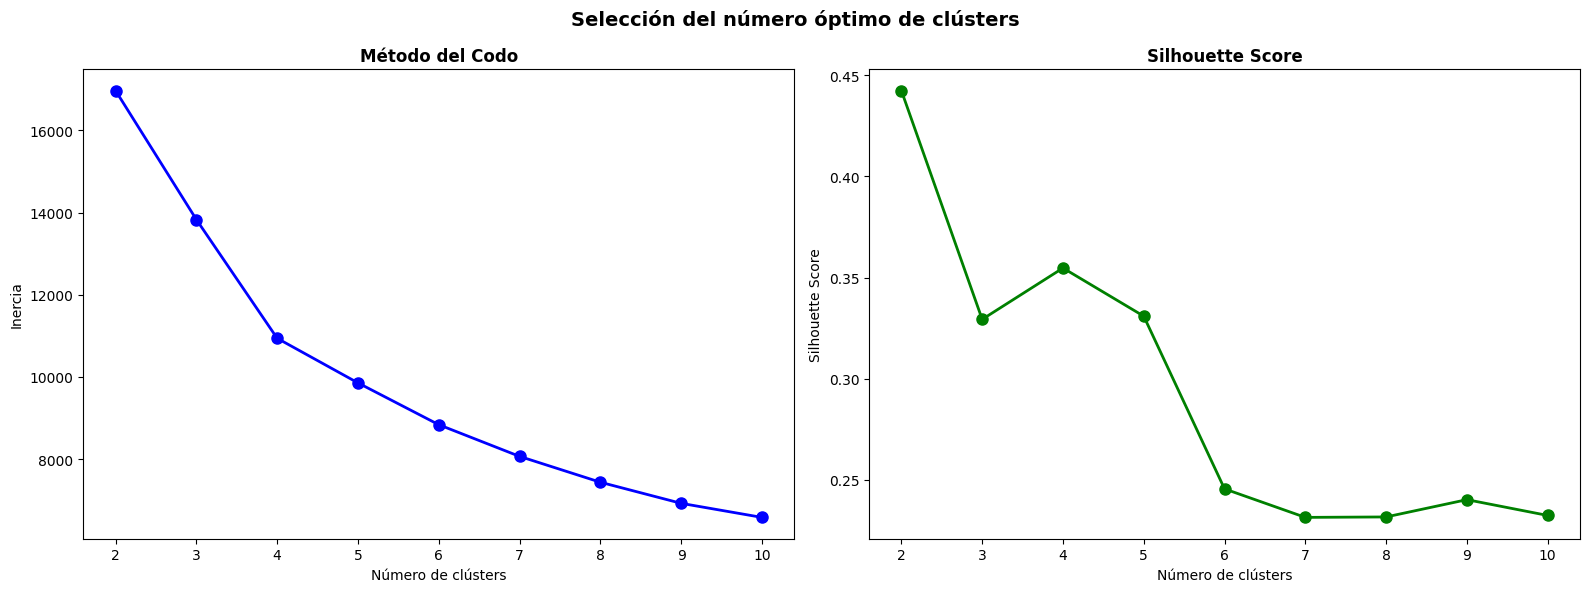

In [28]:
# Método del codo + Silhouette para determinar K óptimo para el etiquetados de ciudades

K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clustering)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clustering, labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Método del codo
axes[0].plot(K_range, inertias, 'o-', color='blue', linewidth=2, markersize=8)
axes[0].set_title('Método del Codo', fontweight='bold')
axes[0].set_xlabel('Número de clústers')
axes[0].set_ylabel('Inercia')
axes[0].set_xticks(list(K_range))

# Silhouette Score
axes[1].plot(K_range, silhouettes, 'o-', color='green', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Número de clústers')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))

fig.suptitle('Selección del número óptimo de clústers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


- Gracias a la gráfica del método del codo podemo sver que un posible número de clústers óptimo es 4. 
- Y en la gráfica de Silhouette Score se puede ver que 2 clústers tienen mejor score, pero el siguiente serían 4 (0.35). 

### **Entrenamos distintos modelos de clustering de ciudades como destino nómada**

In [29]:
# Entrenamos modelo K-Means con K óptimo

best_k = 4 # Este número sale lógicamente del análisis previo

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clustering['cluster'] = kmeans.fit_predict(X_clustering)

In [30]:
# Analizamos las métricas del modelo 

sil_score = silhouette_score(X_clustering, df_clustering['cluster']) 

print(f'K-Means (K) = {best_k}:')
print(f'Silhouette Score: {sil_score:.2f}')
print(f'\nDistribución de clusters:')
print(df_clustering['cluster'].value_counts().sort_index())

K-Means (K) = 4:
Silhouette Score: 0.35

Distribución de clusters:
cluster
0    1329
1    2179
2    1081
3     153
Name: count, dtype: int64


- Aquí tenemos el reparto de clústers de ciudades a partir del número óptimo evaluado previamente. 
- De total de 4742 ciudades, 1329 están en el clúster 0, otras 2179 en el clúster 1, 1081 en el clúster 2 y 153 en el clúster 3. 

In [31]:
# Entrenamos un modelo DBSCAN 

dbscan = DBSCAN(eps=1.5, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_clustering)

# El algoritmo
print(dbscan)

# Todos los datos etiquetados
print(len(dbscan.labels_))

# Los 10 primeros labels
print(dbscan.labels_[:10])

# Cuantos clústers ha montado
print(np.unique(dbscan.labels_))

DBSCAN(eps=1.5, min_samples=10)
4742
[ 0  0  0  0  0  0  0  0  0 -1]
[-1  0]


In [32]:
# Aquí hacemos lo mismo con un modelo de clústering jerárquico 

agglo_clustering = AgglomerativeClustering(n_clusters=best_k)
labels_agglo_clustering = agglo_clustering.fit_predict(X_clustering)
sil_score_agglo_clustering = silhouette_score(X_clustering, labels_agglo_clustering)

print(f'Silhouette Score: {sil_score_agglo_clustering:.2f}')

Silhouette Score: 0.35


- Seleccionamos K-means a Sil Score empatados entre K-means y clustering jerárquico.
- Aplicamos clusterizado. 

In [33]:
# Aplicamos primero una PCA con dos componentes para hacer una visualización de los datos en 2 dimensiones (scatter plot) 

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clustering)

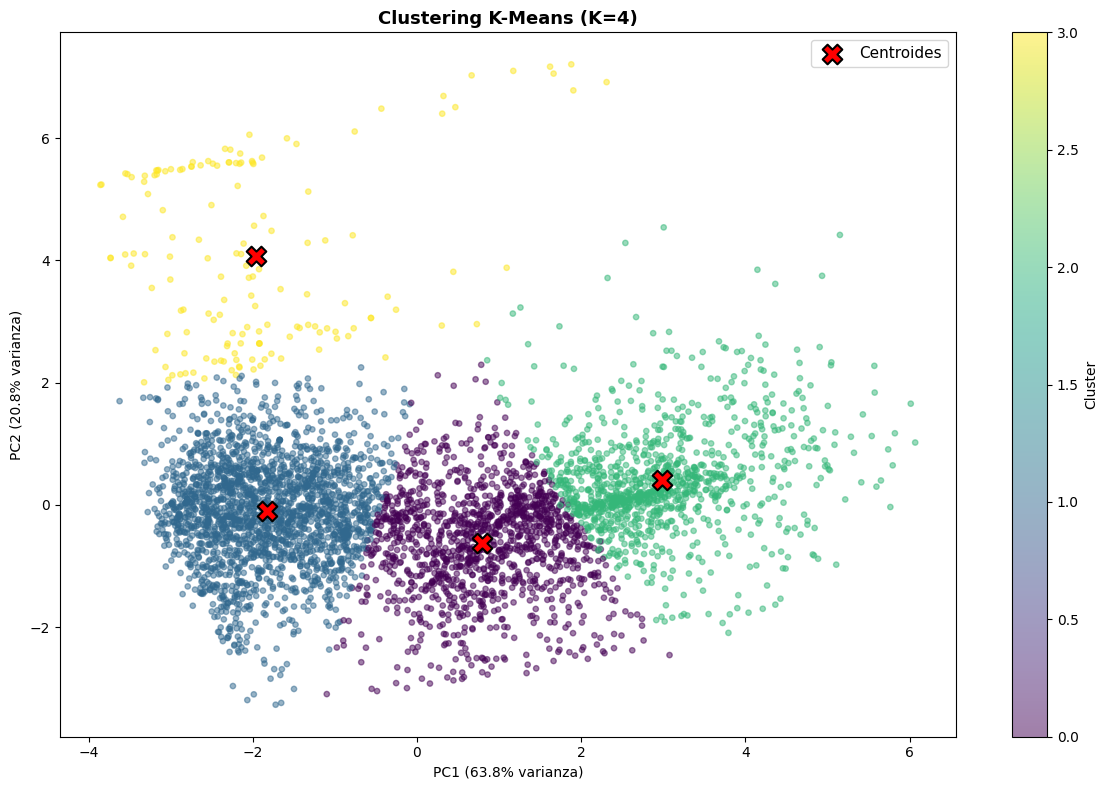

In [34]:
# Y ahora visualizamos los clústers K 

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(X_pca[:, 0], 
                     X_pca[:, 1], 
                     c=df_clustering['cluster'],
                     cmap='viridis', 
                     alpha=0.5, 
                     s=15)

centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], 
           centroids_pca[:, 1], 
           c='red', 
           marker='X',
           s=200, 
           edgecolors='black', 
           linewidths=1.5, 
           zorder=5, 
           label='Centroides')

ax.set_title(f'Clustering K-Means (K={best_k})', fontweight='bold', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
plt.colorbar(scatter, label='Cluster')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### **Extraemos conclusiones del clusterizado de ciudades como destinos para nómadas digitales**

In [35]:
# Perfilado de clusters de ciudades: estadísticos descriptivos por cluster

cluster_cities = df_clustering.groupby('cluster')[nom_features].mean().round(2)

print('Descriptivos medios de las variables agregadas por clúster de ciudades')
display(cluster_cities)

Descriptivos medios de las variables agregadas por clúster de ciudades


,monthly_nomad_cost,nomad_housing_cost,basic_basket_index,daily_meal_cost,local_purchasing_power,cappuccino_index,housing_salary_ratio
cluster,,,,,,,
0,1278.51,677.43,2.68,16.46,2.01,29.31,28.93
1,520.28,238.44,1.44,6.93,1.14,15.58,44.94
2,2150.38,1376.15,3.82,22.10,1.82,43.05,38.56
3,870.90,532.50,1.89,6.88,0.31,17.41,198.47


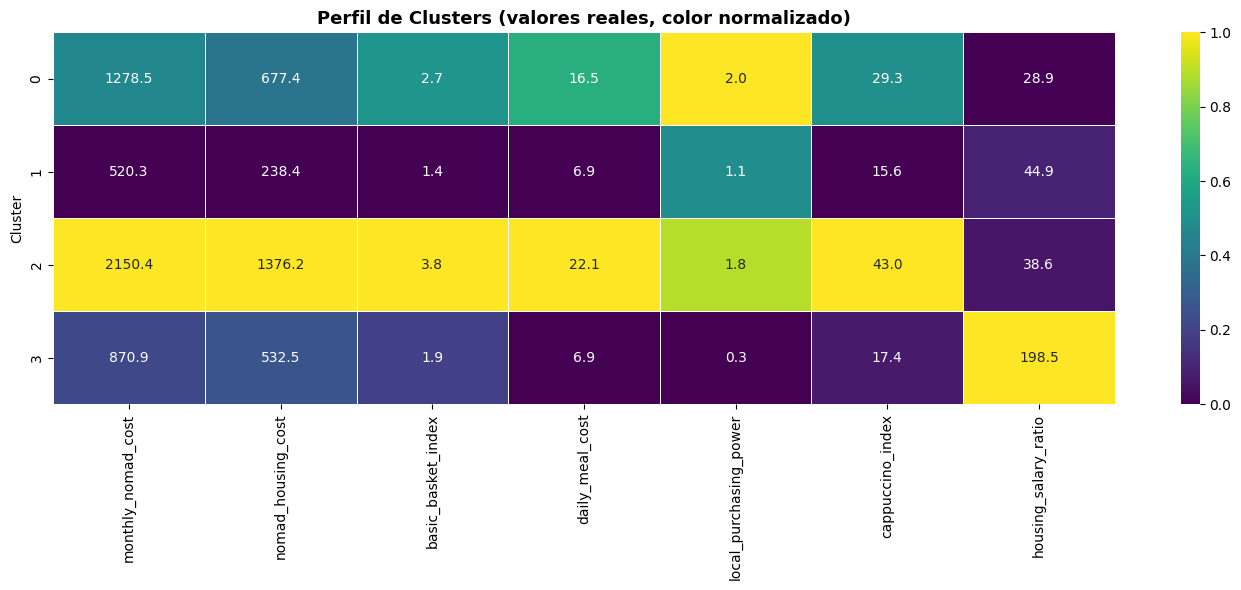

In [36]:
# Heatmap con la relación de clusters de ciudades y variables --> los descriptivos pero en heatmap
# Antes de hacerlo tenemos que usar alguna técnica que normalice los rangos --> MinMaxScaler 

cluster_cities_norm = (cluster_cities - cluster_cities.min()) / (cluster_cities.max() - cluster_cities.min())

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(cluster_cities_norm, 
            annot=cluster_cities.values, 
            fmt='.1f',
            cmap='viridis', 
            ax=ax, 
            linewidths=0.5)
ax.set_title('Perfil de Clusters (valores reales, color normalizado)', fontweight='bold', fontsize=13)
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

- Aquí vemos que el clúster 1 son las ciudades más baratas para vivir. Clúster 3, coste medio. Clúster 0 algo más caras. Clúster 2, las más caras. 
- Y si vamos a la métricas de % de salario invertido en vivienda, las ciudades con peor ratio son las del clúster 3. 

In [38]:
# Asignar etiquetas de negocio a cada cluster basándose en los perfiles
# Ordenar clusters por monthly_nomad_cost para asignar etiquetas coherentes

ordered_cluster_cities = cluster_cities['monthly_nomad_cost'].sort_values().index.tolist()

print('Clústers ordenados por coste mensual:')
for order, c in enumerate(ordered_cluster_cities):
    cost = cluster_cities.loc[c, 'monthly_nomad_cost']
    power = cluster_cities.loc[c, 'local_purchasing_power']
    n = (df_clustering['cluster'] == c).sum()
    print(f'  Clúster {c}: Coste: {cost:.0f} USD / Poder adquisitivo: {power:.2f} / Número de ciudades: {n}')

Clústers ordenados por coste mensual:
  Clúster 1: Coste: 520 USD / Poder adquisitivo: 1.14 / Número de ciudades: 2179
  Clúster 3: Coste: 871 USD / Poder adquisitivo: 0.31 / Número de ciudades: 153
  Clúster 0: Coste: 1279 USD / Poder adquisitivo: 2.01 / Número de ciudades: 1329
  Clúster 2: Coste: 2150 USD / Poder adquisitivo: 1.82 / Número de ciudades: 1081


In [39]:
# Top 5 ciudades más representativas de cada clúster

centroids = kmeans.cluster_centers_

for c in sorted(df_clustering['cluster'].unique()):
    mask = df_clustering['cluster'] == c
    distances = np.linalg.norm(X_clustering[mask.values] - centroids[c], axis=1)
    
    # Índices de las 5 más cercanas al centroide

    top5_idx = np.argsort(distances)[:5]
    top5 = df_clustering[mask].iloc[top5_idx][['city_name', 'country_name',
                                                'monthly_nomad_cost', 'local_purchasing_power']].copy()
    top5['distancia_centroide'] = distances[top5_idx].round(3)
    
    print(f'Clúster {c} — Top 5 ciudades más representativas')
    display(top5.reset_index(drop=True))

Clúster 0 — Top 5 ciudades más representativas


,city_name,country_name,monthly_nomad_cost,local_purchasing_power,distancia_centroide
0,Lille,France,1315.315,2.036189,0.214
1,Reims,France,1227.840,1.902365,0.327
2,Laval,Canada,1272.355,2.148787,0.341
3,Lorient,France,1201.755,1.941028,0.344
4,Montevrain,France,1135.620,1.855806,0.374


Clúster 1 — Top 5 ciudades más representativas


,city_name,country_name,monthly_nomad_cost,local_purchasing_power,distancia_centroide
0,Santo Andre,Brazil,558.9800,1.113958,0.171
1,Sibiu,Romania,570.1050,1.103586,0.222
2,Campinas,Brazil,572.3000,1.049869,0.226
3,Tulcan,Ecuador,536.7775,1.117782,0.267
4,Targu-Mures,Romania,624.0000,1.143606,0.267


Clúster 2 — Top 5 ciudades más representativas


,city_name,country_name,monthly_nomad_cost,local_purchasing_power,distancia_centroide
0,Reykjavik,Iceland,2060.020,1.622746,0.355
1,Eden Prairie,United States,2144.370,1.756539,0.384
2,Arroyo Grande,United States,2015.965,1.868420,0.408
3,Evanston,United States,2155.415,1.762074,0.429
4,Baker,United States,2063.175,1.825667,0.438


Clúster 3 — Top 5 ciudades más representativas


,city_name,country_name,monthly_nomad_cost,local_purchasing_power,distancia_centroide
0,Vanadzor,Armenia,732.5600,0.310432,0.296
1,Beira,Mozambique,866.2825,0.301322,0.321
2,Tete,Mozambique,883.9575,0.295297,0.344
3,City of Paranaque,Philippines,789.1250,0.341049,0.544
4,Niamey,Niger,1012.0750,0.208986,0.689


In [40]:
# Guardamos modelo Kmeans y scaler de clustering

joblib.dump(kmeans, '../models/clustering_kmeans.joblib')
joblib.dump(scaler_clustering, '../models/scaler_clustering.joblib')

['../models/scaler_clustering.joblib']

## Explicacion de regression, etc...

### Preprocessing

In [41]:
# Agregar Cost of Living a nivel país (media de todas las ciudades)

num_cols = df_cities.select_dtypes(include="number").columns.tolist()
df_countries = df_cities.groupby("country_name")[num_cols].mean().reset_index()

In [42]:
# Añadir continente (moda por país)

country_continent = df_cities.groupby("country_name")["continent"].first().reset_index()
df_countries = df_countries.merge(country_continent, on="country_name")

In [43]:
# Añadir número de ciudades por país

city_count = df_cities.groupby("country_name").size().reset_index(name="city_count")
df_countries = df_countries.merge(city_count, on="country_name")

In [44]:
# Merge con Circleloop (inner join)

df_regression = df_countries.merge(df_circleloop, left_on="country_name", right_on="country", how="inner")

Análisis de colinealidad entre variables y selección para el modelo

El objetivo es predecir nuestro targe `digital_nomad_score`. La predicción se basa en los indicadores de coste de vida, conectividad, bienestar...

In [45]:
# Selección de features para el modelo de regresión lineal

# Excluimos:
# 1. El propio target de digital_nomad_score.
# 2. "rank" como variable por forma parte del cálculo del propio score
# 3. Columnas de identificación como nombre de país, continente..

exclude_cols = [
	"country_name",
	"country",
	"continent",
	"data_quality_flag",
	"digital_nomad_score",
	"rank",
	"rank_x",
	"rank_y",
	"cluster_dominant"
]

feature_candidates = []

num_cols = df_regression.select_dtypes(include="number").columns

for c in num_cols:
	if c not in exclude_cols:
		feature_candidates.append(c)

print(f"Variables candidatas: {len(feature_candidates)}")

Variables candidatas: 69


In [46]:
corr_matrix = df_regression[feature_candidates].corr()

plt.figure(dpi=200, figsize=(50, 50))
sns.heatmap(
	corr_matrix,
	annot=True,
	fmt=".2f",
	cmap="viridis",
	center=0
)
plt.title("Matriz de correlación de variables")
plt.show()


In [47]:
# Creamos matriz de correlación
corr_matrix = df_regression[feature_candidates].corr().abs()

# Seleccionamos el triángulo superior de la matriz
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificamos columnas con correlación superior al umbral
to_drop = []

for column in upper.columns:
	if any(upper[column] > 0.8):
		to_drop.append(column)

# Eliminamos las variables
df_filtered = df_regression.drop(columns=to_drop)

In [48]:
# Variables que servirán para el cálculo del modelo de regresión

feature_candidates_reduced = []

for c in feature_candidates:
	if c not in to_drop:
		feature_candidates_reduced.append(c)

print(f"Variables tras reducción: {len(feature_candidates_reduced)}")

Variables tras reducción: 38


#### Unificado

In [50]:
# Creamos un resumen estadístico de un DataFrame para ver qué tan "limpios" están los datos.
def get_quality(dataframe: pd.DataFrame) -> pd.DataFrame:
	if dataframe is None:
		raise ValueError("Dataframe sin especificar.")

	if not isinstance(dataframe, pd.DataFrame):
		raise ValueError("El dataframe debe ser pd.DataFrame")

	records = dataframe.shape[0]

	unique = dataframe.nunique().rename("Cardinality")
	cardinality = (unique/records).rename("Uniqueness")
	null = (dataframe.isna().sum()).rename("Null")

	data = pd.DataFrame(data=[unique, cardinality, null])

	return data.T

- Hacemos un analisis de consistencia entre circleloop y movingto: 

In [51]:
countries_from_circle = df_circleloop["country"].unique()
countries_from_movingto = df_movingto["country"].unique()

In [52]:
print("Países de circleloop dataset:", len(countries_from_circle))
print("Países de movingto dataset:", len(countries_from_movingto))

Países de circleloop dataset: 85
Países de movingto dataset: 40


In [53]:
intersection = len(set(countries_from_circle).intersection(set(countries_from_movingto)))
print("Intersección entre circle y movingto:", intersection, "países")

Intersección entre circle y movingto: 34 países


In [54]:
df_merged = pd.merge(
	left=df_circleloop,
	right=df_movingto,
	how="left",
	on="country"
)

In [55]:
get_quality(df_merged)

,Cardinality,Uniqueness,Null
rank_x,85.0,1.000000,0.0
country,85.0,1.000000,0.0
broadband_speed_mbps,84.0,0.988235,0.0
mobile_speed_mbps,85.0,1.000000,0.0
broadband_cost,84.0,0.988235,0.0
monthly_rent,80.0,0.941176,0.0
happiness_index,74.0,0.870588,0.0
migrant_population_pct,63.0,0.741176,0.0
remote_jobs_searches,80.0,0.941176,0.0
digital_nomad_score,84.0,0.988235,0.0


- Transformamos la columna *`taxes`*:

In [56]:
import re


def taxes_formatter(value):
	if isinstance(value, type(np.nan)):
		return {
			"tax_min": None,
			"tax_max": None
		}

	pattern = r"(?P<min>\d{0,2}[\d\.]{0,2})[%-]?(?P<max>\d{0,2}[\d\.]{0,3})[%]?"
	is_match = re.search(pattern, value, re.IGNORECASE)
	if is_match:
		match_min = is_match.group("min") if is_match.group("max") else None
		match_max = is_match.group("min") if not is_match.group("max") else is_match.group("max")

		return {
			"tax_min": match_min,
			"tax_max": match_max
		}

taxes_data = df_merged["taxes"].apply(taxes_formatter)
data = pd.DataFrame(taxes_data.tolist())
df_merged = pd.concat([df_merged, data], axis=1)

In [57]:
df_merged["tax_min"] = df_merged["tax_min"].replace([""], np.nan)
df_merged["tax_max"] = df_merged["tax_max"].replace([""], np.nan)

df_merged["tax_min"] = df_merged["tax_min"].astype(float)
df_merged["tax_max"] = df_merged["tax_max"].astype(float)

In [58]:
df_merged["tax_mean"] = (df_merged["tax_min"] + df_merged["tax_max"]) / 2

In [59]:
maps = {
	"tax_min": "unknown",
	"tax_max": "unknown",
	"tax_mean": "unknown"
}

df_merged.fillna(maps, inplace=True)

- Extraemos los datos de *`tax_free_period`*:

In [60]:
def taxperiod_formatter(value):
	if isinstance(value, type(np.nan)):
		return {
			"tax_time": None,
			"tax_period": None
		}

	split = value.split(" ")
	return {
		"tax_time": split[0],
		"tax_period": split[1],
	}


data = pd.DataFrame(df_merged["tax_free_period"].apply(taxperiod_formatter).tolist())
df_merged = pd.concat([df_merged, data], axis=1)

In [61]:
df_merged["tax_time"] = df_merged["tax_time"].astype(float)

In [62]:
def normalize_taxperiod(value):
	if isinstance(value, type(np.nan)):
		return None

	if value:
		if "day" in value.lower():
			return "day"
		elif "year" in value.lower() and "/" not in value.lower():
			return "year"

df_merged["tax_period"] = df_merged["tax_period"].apply(normalize_taxperiod)

- Normalizamos la unidad de medida en días:

In [63]:
conditions = [
	df_merged["tax_period"].str.lower() == "day",
	df_merged["tax_period"].str.lower() == "year"
]

choices = [
	df_merged["tax_time"].astype(float) * 1,
	df_merged["tax_time"].astype(float) * 365,
]

df_merged["tax_time"] = np.select(conditions, choices)

In [64]:
df_merged["tax_time"] = df_merged["tax_time"].apply(lambda x: "unknow" if x == 0 else x)

In [65]:
df_merged.head()

,rank_x,country,broadband_speed_mbps,mobile_speed_mbps,broadband_cost,monthly_rent,happiness_index,migrant_population_pct,remote_jobs_searches,digital_nomad_score,...,safety,visa_ease,quality_of_life,taxes,tax_free_period,tax_min,tax_max,tax_mean,tax_time,tax_period
0,1,Canada,149.35,84.54,41.17,1045.0,7.23,21.3,83900,74.35,...,90.0,80.0,95.0,15-33%,183 days/year,15.0,33.0,24.0,183.0,day
1,2,UK,76.49,41.72,42.18,1019.7,7.17,14.1,68400,63.43,...,NaN,NaN,NaN,NaN,NaN,unknown,unknown,unknown,unknow,None
2,3,Romania,188.55,41.48,9.63,357.5,6.12,2.4,10980,62.28,...,75.0,80.0,75.0,10%,183 days/year,unknown,10.0,unknown,183.0,day
3,4,Sweden,158.73,56.64,46.77,973.5,7.35,20.0,3490,61.54,...,90.0,80.0,95.0,0-57%,183 days/year,0.0,57.0,28.5,183.0,day
4,5,Denmark,179.81,66.68,56.96,1164.9,7.65,12.5,1080,61.49,...,NaN,NaN,NaN,NaN,NaN,unknown,unknown,unknown,unknow,None


- Categorizamos la media de tax en `low`, `medium` o `high`:

In [66]:
def categorize_taxmean(value):
    if isinstance(value, str):
        return value
    elif value < 15:
        return "Low"
    elif value < 30:
        return "Medium"
    else:
        return "High"

df_merged["tax_category"] = df_merged["tax_mean"].apply(categorize_taxmean)

- Categorizamos tax free en `short`, `medium` o `long`:

In [67]:
def categorize_tax_freeperiod(value):
    if isinstance(value, str):
        return value
    elif value <= 365:
        return "Short"
    elif value <= 1825:
        return "Medium"
    else:
        return "Long"

df_merged["tax_free_category"] = df_merged["tax_time"].apply(categorize_tax_freeperiod)

- Eliminamos nuestras columnas que sobran:

In [68]:
to_delete = [
    "taxes", "tax_free_period", "tax_min", "tax_max", "tax_mean", "tax_time", "tax_period"
]
df_merged.drop(columns=to_delete, inplace=True)

In [69]:
df_merged.head()

,rank_x,country,broadband_speed_mbps,mobile_speed_mbps,broadband_cost,monthly_rent,happiness_index,migrant_population_pct,remote_jobs_searches,digital_nomad_score,rank_y,overall_score,internet_speed,cost_of_living,safety,visa_ease,quality_of_life,tax_category,tax_free_category
0,1,Canada,149.35,84.54,41.17,1045.0,7.23,21.3,83900,74.35,16.0,77.0,85.0,60.0,90.0,80.0,95.0,Medium,Short
1,2,UK,76.49,41.72,42.18,1019.7,7.17,14.1,68400,63.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknow
2,3,Romania,188.55,41.48,9.63,357.5,6.12,2.4,10980,62.28,32.0,61.0,85.0,85.0,75.0,80.0,75.0,unknown,Short
3,4,Sweden,158.73,56.64,46.77,973.5,7.35,20.0,3490,61.54,40.0,53.0,90.0,55.0,90.0,80.0,95.0,Medium,Short
4,5,Denmark,179.81,66.68,56.96,1164.9,7.65,12.5,1080,61.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknow


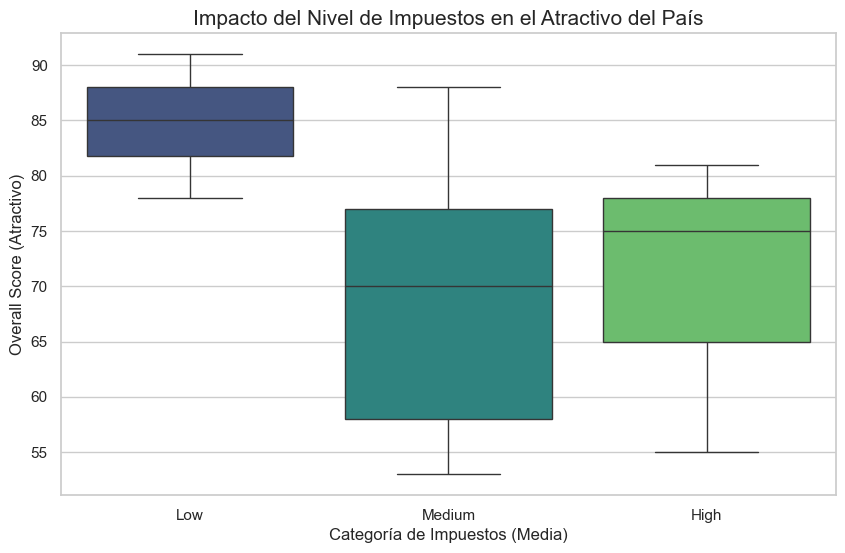

In [70]:
# Configuramos el estilo
sns.set_theme(style="whitegrid")

# Creamos el gráfico de caja
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_merged[df_merged["tax_category"] != "unknown"], 
    x="tax_category", 
    y="overall_score", 
    order=["Low", "Medium", "High"],
    palette="viridis"
)

plt.title("Impacto del Nivel de Impuestos en el Atractivo del País", fontsize=15)
plt.xlabel("Categoría de Impuestos (Media)", fontsize=12)
plt.ylabel("Overall Score (Atractivo)", fontsize=12)

plt.show()

#### Análisis de Impacto Fiscal (Boxplot): 

- Correlación Directa: Los países con impuestos bajos ("`Low`") presentan el mayor atractivo, con una mediana de *overall_score* superior a 85 puntos.

- Consistencia: El segmento "``Low``" es el más estable, mientras que el nivel "``Medium``" muestra la mayor dispersión, indicando que en este rango el atractivo depende de otros factores como conectividad o seguridad.

- Compensación: Los países con impuestos altos ("``High``") logran mantener un piso de atractivo competitivo (score > 55), sugiriendo que compensan la carga fiscal con infraestructura y calidad de vida.

## Iniciamos con modelados:

### 1. Modelo baseline: `ElasticNet`

In [71]:
from sklearn.linear_model import ElasticNet

In [72]:
features = df_merged.iloc[:, 2:9].columns

# Variable objetivo a predecir
target = "digital_nomad_score"

### TRAIN/TEST SPLIT

In [73]:
df_train, df_test = train_test_split(df_merged, test_size=.2)

In [74]:
df_train_scaled = df_train.copy()
df_test_scaled = df_test.copy()

In [75]:
standard_scaler = StandardScaler()
standard_scaler.set_output(transform="pandas")

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [76]:
data = standard_scaler.fit_transform(df_train_scaled[features])
df_train_scaled[features] = data

data = standard_scaler.fit_transform(df_test_scaled[features])
df_test_scaled[features] = data

### Modelo baseline
#### `ElasticNet`

Elegimos como modelo base un modelo simple como es `ElasticNet` ya que es un modelo que se puede explicar facilmente.

In [77]:
elastic_net = ElasticNet(max_iter=2000)
elastic_net.fit(df_train_scaled[features], df_train_scaled[target])

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",2000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


- Para abordar la Pregunta de Negocio 2, se implementó un modelo de regresión ``ElasticNet``. Este algoritmo es ideal para este dataset ya que combina las penalizaciones L1 y L2, permitiendo manejar la correlación entre variables y realizar una selección automática de las características más influyentes.

- Variables Predictoras (Features): Se definieron 7 dimensiones clave que abarcan conectividad (velocidad de internet), costo de vida (renta y servicios) y bienestar (índice de felicidad). Se excluyeron identificadores como el nombre del país para evitar sesgos.

- Preprocesamiento: Se utilizó StandardScaler para normalizar las escalas de las variables, asegurando que unidades distintas (Mbps vs. USD) sean comparables para el modelo.

- Configuración: El modelo utiliza un l1_ratio=0.5 y un alpha=1.0, buscando un equilibrio entre la simplificación del modelo y la precisión predictiva.

#### `Feature Importance`

Analizamos la `feature importance` del modelo:

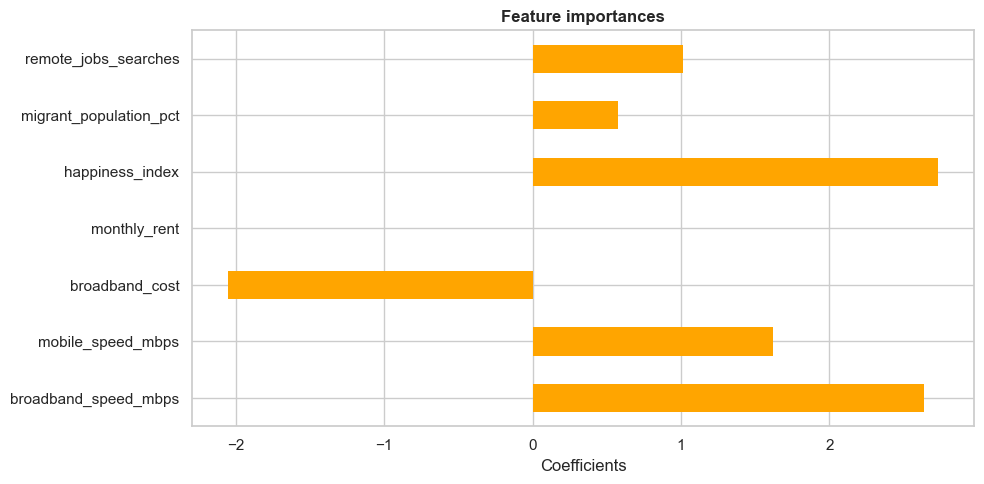

In [78]:
fi = pd.DataFrame(
    elastic_net.coef_,
    index=elastic_net.feature_names_in_,
    columns=["feature importance"]
)

fig, ax = plt.subplots(figsize=(10, 5))
fi.plot(kind="barh", ax=ax, color="orange", legend=False, edgecolor="none")
ax.set_title(
    "Feature importances",
    fontweight="bold"
)
ax.set_xlabel("Coefficients")
plt.tight_layout()
plt.show()

El modelo identifica los pesos matemáticos que definen el atractivo de un país:

- Principales Impulsores: ``El Happiness Index`` y la ``Broadband Speed`` son los factores con mayor impacto positivo. Esto indica que la calidad de vida y una conexión sólida son los requisitos no negociables para los nómadas.

- Barrera Crítica: El ``Broadband Cost`` presenta una correlación negativa marcada; a mayor costo de internet, disminuye drásticamente el atractivo del destino.

- Factores Secundarios: Variables como la renta mensual y las búsquedas de empleo remoto tienen un peso menor, sugiriendo que el bienestar y la conectividad base dominan la decisión por encima del costo de vivienda.

In [79]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import root_mean_squared_error, r2_score

results = cross_validate(
    estimator=elastic_net,
	X=df_train_scaled[features],
	y=df_train_scaled[target],
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring=["neg_root_mean_squared_error", "r2"],
	n_jobs=-1
)

print("TRAIN")
print("-"*10)
rmse = np.mean(-results["test_neg_root_mean_squared_error"])
print(f"RMSE:", round(rmse, 2))

r2 = np.mean(results["test_r2"])
print(f"R2:", round(r2, 2))

print()

print("TEST")
print("-"*10)
predicts = elastic_net.predict(df_test_scaled[features])
rmse = root_mean_squared_error(df_test_scaled[target], predicts)
print(f"RMSE:", round(rmse, 2))

r2 = r2_score(df_test_scaled[target], predicts)
print(f"R2:", round(r2, 2))

TRAIN
----------
RMSE: 5.72
R2: 0.65

TEST
----------
RMSE: 5.39
R2: 0.68


El modelo tiene un buen rendimiento. No realiza overfitting y está generalizando correctamente.

####  `Fine Tuning`

In [80]:
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV

params = {
   "alpha": loguniform(.0005, 5),
   "l1_ratio": loguniform(.0005, 1)
}

randomized_search = RandomizedSearchCV(
    estimator=ElasticNet(max_iter=2000),
    param_distributions=params,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1)
randomized_search.fit(
    df_train_scaled[features],
    df_train_scaled[target]
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet(max_iter=2000)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'alpha': <scipy.stats....0022C465FAC30>, 'l1_ratio': <scipy.stats....0022C465FAF00>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv``

In [81]:
best_params = randomized_search.best_params_
best_params

{'alpha': np.float64(0.03967318308755348),
 'l1_ratio': np.float64(0.002698961355016974)}

In [82]:
elastic_net = ElasticNet(**best_params, max_iter=2000)
elastic_net.fit(df_train_scaled[features], df_train_scaled[target])

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",np.float64(0....7318308755348)
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",np.float64(0....8961355016974)
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",2000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [83]:
results = cross_validate(
    estimator=elastic_net,
	X=df_train_scaled[features],
	y=df_train_scaled[target],
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring=["neg_root_mean_squared_error", "r2"],
	n_jobs=-1
)

print("TRAIN")
print("-"*10)
rmse = np.mean(-results["test_neg_root_mean_squared_error"])
print(f"RMSE:", round(rmse, 2))

r2 = np.mean(results["test_r2"])
print(f"R2:", round(r2, 2))

print()

print("TEST")
print("-"*10)
predicts = elastic_net.predict(df_test_scaled[features])
rmse = root_mean_squared_error(df_test_scaled[target], predicts)
print(f"RMSE:", round(rmse, 2))

r2 = r2_score(df_test_scaled[target], predicts)
print(f"R2:", round(r2, 2))

TRAIN
----------
RMSE: 5.04
R2: 0.7

TEST
----------
RMSE: 4.39
R2: 0.79


Hemos logrado bajal el error con *RandomizedSearch*. El modelo sigue generalizando correctamente.

### 2. `RandomForestRegressor`

Para validar la potencia de nuestro baseline, implementamos un Random Forest, un algoritmo de ensemble que ofrece varias ventajas: Relaciones No Lineales, robustez, Feature Importance de No Linealidad.

In [84]:
random_forest = RandomForestRegressor(n_jobs=1, random_state=42)
random_forest.fit(df_train_scaled[features], df_train_scaled[target])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

#### `Feature Importance`

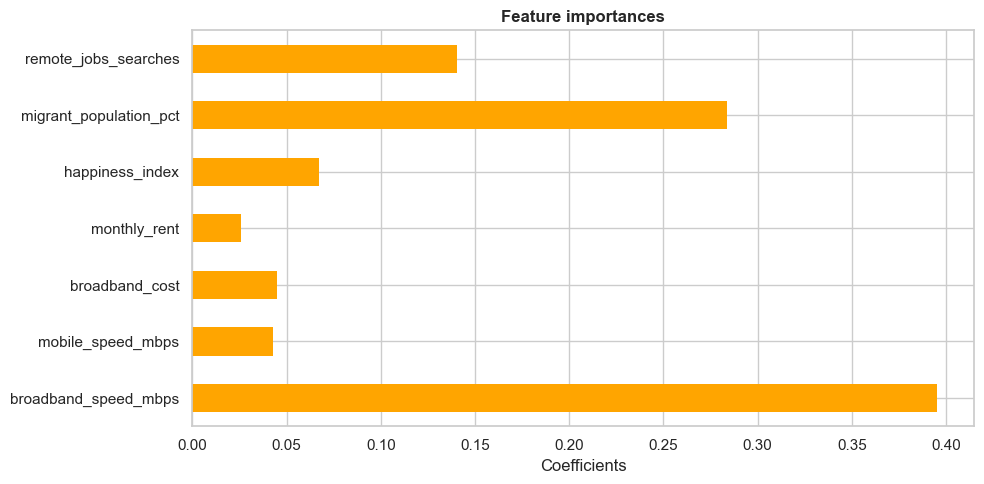

In [85]:
fi = pd.DataFrame(
    random_forest.feature_importances_,
    index=elastic_net.feature_names_in_,
    columns=["feature importance"]
)

fig, ax = plt.subplots(figsize=(10, 5))
fi.plot(kind="barh", ax=ax, color="orange", legend=False, edgecolor="none")
ax.set_title(
    "Feature importances",
    fontweight="bold"
)
ax.set_xlabel("Coefficients")
plt.tight_layout()
plt.show()

In [86]:
results = cross_validate(
    estimator=random_forest,
	X=df_train_scaled[features],
	y=df_train_scaled[target],
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring=["neg_root_mean_squared_error", "r2"],
	n_jobs=-1
)

print("TRAIN")
print("-"*10)
rmse = np.mean(-results["test_neg_root_mean_squared_error"])
print(f"RMSE:", round(rmse, 2))

r2 = np.mean(results["test_r2"])
print(f"R2:", round(r2, 2))

print()

print("TEST")
print("-"*10)
rmse = root_mean_squared_error(df_test_scaled[target], predicts)
print(f"RMSE:", round(rmse, 2))

r2 = r2_score(df_test_scaled[target], predicts)
print(f"R2:", round(r2, 2))

TRAIN
----------
RMSE: 5.3
R2: 0.7

TEST
----------
RMSE: 4.39
R2: 0.79


#### `Fine Tuning`

In [87]:
params = {
	"n_estimators": [100, 300, 500],
	"max_depth": [None, 5, 10, 20],
	"min_samples_split": [2, 5, 10],
	"min_samples_leaf": [1, 2, 4],
	"max_features": ["sqrt", "log2", 0.5],
	"bootstrap": [True]
}

grid_search = GridSearchCV(
	estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
	param_grid=params,
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring="neg_root_mean_squared_error",
	n_jobs=-1
)
grid_search.fit(df_train_scaled[features], df_train_scaled[target])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messag

In [88]:
best_params = grid_search.best_params_
best_params

{'bootstrap': True,
 'max_depth': None,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [89]:
random_forest = RandomForestRegressor(
	**best_params,
	n_jobs=-1,
	random_state=42
)
random_forest.fit(df_train_scaled[features], df_train_scaled[target])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [90]:
data = standard_scaler.fit_transform(df_train_scaled[features])
df_train_scaled[features] = data

data = standard_scaler.fit_transform(df_test_scaled[features])
df_test_scaled[features] = data

In [91]:
results = cross_validate(
	random_forest,
	df_train_scaled[features],
	df_train_scaled[target],
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring=["neg_root_mean_squared_error", "r2"],
	n_jobs=-1
)

print("TRAIN")
print("-"*10)
rmse = np.mean(-results["test_neg_root_mean_squared_error"])
print(f"RMSE:", round(rmse, 2))

r2 = np.mean(results["test_r2"])
print(f"R2:", round(r2, 2))

print()

print("TEST")
print("-"*10)
predicts = random_forest.predict(df_test_scaled[features])
rmse = root_mean_squared_error(df_test_scaled[target], predicts)
print(f"RMSE:", round(rmse, 2))

r2 = r2_score(df_test_scaled[target], predicts)
print(f"R2:", round(r2, 2))

TRAIN
----------
RMSE: 5.09
R2: 0.73

TEST
----------
RMSE: 6.22
R2: 0.57


### `XGBoost`

In [92]:
from xgboost import XGBRegressor

In [93]:
xgboost = XGBRegressor(
	objective="reg:squarederror",
	n_jobs=-1,
	random_state=42
)
xgboost.fit(df_train_scaled[features], df_train_scaled[target])

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

#### `Feature Importance`

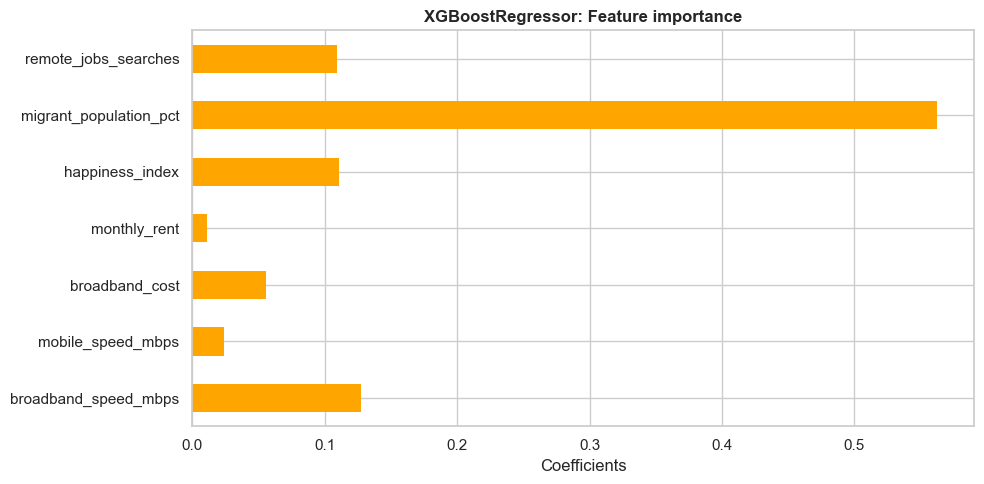

In [94]:
fi = pd.DataFrame(
	xgboost.feature_importances_,
	index=xgboost.feature_names_in_,
	columns=["feature importance"]
)

fig, ax = plt.subplots(figsize=(10, 5))
fi.plot(kind="barh", ax=ax, color="orange", legend=False, edgecolor="none")
ax.set_title(
	"XGBoostRegressor: Feature importance",
	fontweight="bold"
)
ax.set_xlabel("Coefficients")
plt.tight_layout()
plt.show()

In [95]:
results = cross_validate(
	xgboost,
	df_train_scaled[features],
	df_train_scaled[target],
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring=["neg_root_mean_squared_error", "r2"],
	n_jobs=-1
)

print("TRAIN")
print("-"*10)
rmse = np.mean(-results["test_neg_root_mean_squared_error"])
print(f"RMSE:", round(rmse, 2))

r2 = np.mean(results["test_r2"])
print(f"R2:", round(r2, 2))

print()

print("TEST")
print("-"*10)
predicts = xgboost.predict(df_test_scaled[features])
rmse = root_mean_squared_error(df_test_scaled[target], predicts)
print(f"RMSE:", round(rmse, 2))

r2 = r2_score(df_test_scaled[target], predicts)
print(f"R2:", round(r2, 2))

TRAIN
----------
RMSE: 6.55
R2: 0.52

TEST
----------
RMSE: 6.24
R2: 0.57


#### `Fine Tuning`

In [ ]:
params = {
	"n_estimators": [400, 800, 1200],
	"learning_rate": [0.01, 0.03, 0.05, 0.1],
	"max_depth": [2, 3, 4, 6],
	"min_child_weight": [1, 3, 5],
	"subsample": [0.7, 0.85, 1.0],
	"colsample_bytree": [0.7, 0.85, 1.0],
	"gamma": [0, 0.05, 0.1],
	"reg_alpha": [0.0, 0.1, 1.0],
	"reg_lambda": [1.0, 3.0, 10.0],
}

grid_search = GridSearchCV(
	XGBRegressor(objective="reg:squarederror", n_jobs=-1, random_state=42),
	param_grid=params,
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring="neg_root_mean_squared_error",
	n_jobs=-1
)
grid_search.fit(df_train_scaled[features], df_train_scaled[target])

In [ ]:
best_params = grid_search.best_params_
best_params

In [ ]:
xgboost = XGBRegressor(
    colsample_by_tree=1,
    gamma=.05,
    max_depth=4,
    min_child_weight=5,
    n_estimators=1200,
    reg_alpha=0,
    reg_lambda=1,
    subsample=1,
	objective="reg:squarederror",
	n_jobs=-1,
	random_state=42
)
xgboost.fit(df_train_scaled[features], df_train_scaled[target])

In [ ]:
results = cross_validate(
	xgboost,
	df_train_scaled[features],
	df_train_scaled[target],
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring=["neg_root_mean_squared_error", "r2"],
	n_jobs=-1
)

print("TRAIN")
print("-"*10)
rmse = np.mean(-results["test_neg_root_mean_squared_error"])
print(f"RMSE:", round(rmse, 2))

r2 = np.mean(results["test_r2"])
print(f"R2:", round(r2, 2))

print()

print("TEST")
print("-"*10)
predicts = xgboost.predict(df_test_scaled[features])
rmse = root_mean_squared_error(df_test_scaled[target], predicts)
print(f"RMSE:", round(rmse, 2))

r2 = r2_score(df_test_scaled[target], predicts)
print(f"R2:", round(r2, 2))

### Conclusión


De los tres modelos seleccionados, con `ElasticNet` se consiguio el mejor resultado logrando generalización y performance en la métrica objetivo `RMSE`.

```python
TRAIN
----------
RMSE: 4.8
R2: 0.67

TEST
----------
RMSE: 4.94
R2: 0.81
```

In [ ]:
joblib.dump(elastic_net, "../models/elastic_net.joblib")

### Miscellaneous

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [ ]:
target = ["digital_nomad_score"] # Elegimos el target

In [ ]:
# Usamos un modelo RandomForest para elegir variables candidatas finales para el modelo

X_temp = df_regression[feature_candidates_reduced].fillna(0)
y_temp = df_regression[target]

rf_selector = RandomForestRegressor(
	n_estimators=200,
	random_state=42,
	max_depth=4
)
rf_selector.fit(X_temp, y_temp)

importance = pd.Series(
	rf_selector.feature_importances_,
	index=feature_candidates_reduced
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
importance.head(20).sort_values().plot(
	kind="barh",
	ax=ax,
	color="#2A788E",
	edgecolor="white"
)
ax.set_title("Vars por importancia para RandomForest", fontweight="bold", fontsize=13)
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

#### Train-Test Split

In [ ]:
num_features = 12
selected_features = importance.head(num_features).index.tolist()
print(selected_features)

In [ ]:
# Split entre train y test

X = df_regression[selected_features].fillna(0)
y = df_regression["digital_nomad_score"]

X_train, X_test, y_train, y_test = train_test_split(
	X,
	y,
	test_size=0.2,
	random_state=42
)

print(f"Train: {X_train.shape[0]} países ({X_train.shape[0]/len(X):.0%})")
print(f"Test: {X_test.shape[0]} países ({X_test.shape[0]/len(X):.0%})")

In [ ]:
# Comprobamos si las variables van a necesitar escalado debido a la diferencia de magnitudes

fig, ax = plt.subplots(figsize=(20, 15), layout="constrained")
X_train.hist(grid=False, zorder=2, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
# El orden de magnitud nos obliga a escalar las variables

scaler_regression = StandardScaler()
X_train_scaled = scaler_regression.fit_transform(X_train)
X_test_scaled = scaler_regression.transform(X_test)

#### LinearRegression

In [ ]:
# Usamos un modelo de regresión lineal como baseline

baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

In [ ]:
# Hacemos la predicción con los datos de test

y_pred_baseline_train = baseline_model.predict(X_train_scaled)
y_pred_baseline_test = baseline_model.predict(X_test_scaled)

In [ ]:
# Sacamos las métricas principales del modelo baseline de regresión lineal

print("Modelo de regresión lineal:")
print(f"\tTrain R²:  {r2_score(y_train, y_pred_baseline_train):.4f}")
print(f"\tTest R²:   {r2_score(y_test, y_pred_baseline_test):.4f}")
print(f"\tTest RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_baseline_test)):.2f}")
print(f"\tTest MAE:  {mean_absolute_error(y_test, y_pred_baseline_test):.2f}")

#### Otros modelos: `Ridge`, `Lasso`, `ElasticNet`, `RandomForest`, `GradientBoosting`, `SVR`

In [ ]:
# Validación cruzada con otros modelos de regresión para ponerlos a competir

models = {
	"Linear Regression": LinearRegression(),
	"Ridge": Ridge(random_state=42),
	"Lasso": Lasso(random_state=42),
	"ElasticNet": ElasticNet(random_state=42),
	"Random Forest": RandomForestRegressor(random_state=42),
	"Gradient Boosting": GradientBoostingRegressor(random_state=42),
	"SVR": SVR()
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in models.items():
	scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="r2")
	results.append({
		"Modelo": name,
		"CV R² (media)": scores.mean(),
		"CV R² (std)": scores.std()
	})

df_results = pd.DataFrame(results).sort_values("CV R² (media)", ascending=False)

In [ ]:
print("Comparativa de modelos (Cross-Validation k=5)")
display(df_results.reset_index(drop=True))

- En principio el modelo ganador sería Ridge.
- Lo seguirían los modelos de regresión lineal (baseline) y Random Forest.

In [ ]:
# Vamos a ajustar los modelos de Ridge y Random Foreest con hiperparámetros
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

ridge = Ridge()
parametros_ridge = {"alpha": [0.1, 1.0, 10.0, 100.0]}

grid_ridge = GridSearchCV(
	ridge,
	parametros_ridge,
	cv=KFold(n_splits=5, shuffle=True, random_state=42)
)
grid_ridge.fit(X_train_scaled, y_train)

print(f"Mejor alpha para Ridge: {grid_ridge.best_params_}")
print(f"Mejor CV R²: {grid_ridge.best_score_:.4f}")

Al ajustar Ridge con hiperparámetros hemos mejorado algo la métrica.

In [ ]:
rf = RandomForestRegressor(random_state=42)
parametros_rf = {
	"n_estimators": [50, 100, 200],
	"max_depth": [None, 10, 20],
	"min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
	rf,
	parametros_rf,
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	n_jobs=-1
)
grid_rf.fit(X_train_scaled, y_train)

print(f"Mejores parámetros RF: {grid_rf.best_params_}")
print(f"Mejor CV R²: {grid_rf.best_score_:.4f}")

Random Forest no mejora en exceso.

In [ ]:
# Probamos a ajustar Lasso
lasso = Lasso(random_state=42)

parametros_lasso = {
	"alpha": [0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_lasso = GridSearchCV(
	lasso,
	parametros_lasso,
	cv=5,
	scoring="r2"
)


grid_lasso.fit(X_train_scaled, y_train)

print(f"Mejor valor de alpha para Lasso: {grid_lasso.best_params_}")
print(f"Mejor CV R²: {grid_lasso.best_score_:.4f}")

Lasso si mejora con el ajuste con hiperparámetros. Aunque por debajo de Ridge

#### Probamos el modelo ganador contra test

In [ ]:
# Predicción contra test
y_pred = grid_ridge.predict(X_test_scaled)

In [ ]:
# Comparación de métricas

# Calculamos R2 (proporción de varianza explicada)
r2_test = r2_score(y_test, y_pred)

# Calculamos el error cuadrático medio (MSE) y su raíz (RMSE)
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)

# Calculamos el error absoluto medio (MAE)
mae_test = mean_absolute_error(y_test, y_pred)

print(f"R² en Test: {r2_test:.4f}")
print(f"RMSE en Test: {rmse_test:.4f}")
print(f"MAE en Test: {mae_test:.4f}")

In [ ]:
#ses peor predichos (mayores errores)
test_countries = df_regression.iloc[X_test.index][["country_name"]].copy()
test_countries["real"] = y_test.values
test_countries["pre Paídiccion"] = y_pred
test_countries["error_abs"] = np.abs(y_test.values - y_pred)
test_countries = test_countries.sort_values("error_abs", ascending=False)

print("Top 5 países con mayor error de predicción")
display(test_countries.head(5).reset_index(drop=True))

print("Predicciones completas en test")
display(test_countries.sort_values("real", ascending=False).reset_index(drop=True))

#### Guardamos el modelo de regresión

In [ ]:
best_model = grid_ridge.best_estimator_

joblib.dump(best_model, "../models/regressor_nomad_score.joblib")
joblib.dump(scaler_regression, "../models/scaler_regression.joblib")